# Factor Expression Playground

This notebook provides a template for ad-hoc factor research and validation.

## Quick Start

1. Configure parameters in the next cell
2. Run all cells to evaluate your factor expression
3. Inspect results, plots, and summary statistics

## Use Cases

- Validate new factor expressions
- Test NaN handling semantics
- Compare factor behavior across instruments
- Generate factor value series for external analysis

In [ ]:
# ============================================================================
# Configuration Parameters
# ============================================================================
# Modify these parameters to test different scenarios

# Instrument selection
INSTRUMENT_ID = "BTCUSDT-PERP.BINANCE"

# Date range
START_DATE = "2022-01-01"
END_DATE = "2022-06-30"

# ============================================================================
# Factor Expressions
# ============================================================================
# Define your factor expressions here using the factorexp DSL
# Note: Use $ prefix for field references (e.g., $close, $volume, $amt)

# Example 1: Simple moving average
SIMPLE_MA = "TS_Mean($close, 96)"
SIMPLE_QUANTILE = "TS_Quantile($close, 96, 0.8)"
CLOSE = "$close"

# Example 2: Rolling volatility with Z-Score normalization
VOLATILITY = "ZScore(TS_Std($close, 20), 5760)"

# Example 3: VWAP return with conditional filtering
VWAP_RETURN = """Clip(
    ZScore(
        TS_Std(
            When(
                Greater(TS_Delta($volume, 1), 0),
                Div(
                    Sub(Div($amt, $volume), TS_Ref(Div($amt, $volume), 1)),
                    TS_Ref(Div($amt, $volume), 1)
                ),
                Div(0, 0)
            ),
            96
        ),
        5760
    ),
    -2, 2
)"""

# Example 4: Upper expression using Quantile
UPPER_EXPRESSION = """TS_Quantile(
    $volume,
    96,
    0.8
)"""

#smtmny1_ret_to_volume_close_ret_abs_mean_shigh_96
SMTMNY1_RET_TO_VOLUME_CLOSE_RET_ABS_MEAN_SHIGH_96 = """TS_MeanSelQ(
    Abs(Div(TS_Delta(Div($amt, $volume), 1), TS_Ref(Div($amt, $volume), 1))),
    Abs(Div(TS_Delta($close, 1), Mul(TS_Ref($close, 1), $volume))),
    96,
    0.8,
    1.0
)"""

VANILLA_MEAN_SELQ = """TS_MeanSelQ(
    $close,
    $volume,
    96,
    0.8,
    1.0
)"""

CLOSE = "$close"



print("✅ Configuration loaded")
print(f"Instrument: {INSTRUMENT_ID}")
print(f"Date range: {START_DATE} to {END_DATE}")


✅ Configuration loaded
Instrument: BTCUSDT-PERP.BINANCE
Date range: 2022-01-01 to 2022-06-30


In [3]:
# Setup environment
import sys
from pathlib import Path

# Add parent directory to path for imports
notebook_dir = Path.cwd()
research_dir = notebook_dir.parent
backtest_dir = research_dir.parent

if str(backtest_dir) not in sys.path:
    sys.path.insert(0, str(backtest_dir))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from research.utils import (
    evaluate_factor,
    get_available_instruments,
)

# Plotting setup
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ Environment setup complete")

✅ Environment setup complete


In [4]:
# List available instruments
instruments = get_available_instruments()
print(f"Found {len(instruments)} instruments in catalog\n")
print("First 20 instruments:")
for inst in instruments[:20]:
    print(f"  - {inst}")

if INSTRUMENT_ID not in instruments:
    print(f"\n⚠️  Warning: {INSTRUMENT_ID} not found in catalog")
    print(f"Available instruments: {', '.join(instruments[:10])}...")
else:
    print(f"\n✅ {INSTRUMENT_ID} is available")

Found 40 instruments in catalog

First 20 instruments:
  - 1000FLOKIUSDT
  - 1000PEPEUSDT
  - 1000SHIBUSDT
  - AAVEUSDT
  - ADAUSDT
  - ALGOUSDT
  - APTUSDT
  - ARKMUSDT
  - ARUSDT
  - AVAXUSDT
  - AXSUSDT
  - BCHUSDT
  - BNBUSDT
  - BTCUSDT
  - CHZUSDT
  - DOGEUSDT
  - DYDXUSDT
  - EOSUSDT
  - ETCUSDT
  - ETHUSDT

⚠️  Warning: BTCUSDT-PERP.BINANCE not found in catalog
Available instruments: 1000FLOKIUSDT, 1000PEPEUSDT, 1000SHIBUSDT, AAVEUSDT, ADAUSDT, ALGOUSDT, APTUSDT, ARKMUSDT, ARUSDT, AVAXUSDT...


In [6]:
# ============================================================================
# 2. Evaluate Factor Expression
# ============================================================================
# Replace SIMPLE_MA with your expression (e.g., VOLATILITY, VWAP_RETURN, or custom expression)

result = evaluate_factor(
    expression=VWAP_RETURN,
    instrument_id=INSTRUMENT_ID,
    start_date=START_DATE,
    end_date=END_DATE,
    verbose=True,
)

print(f"\n{'='*70}")
print(f"✅ Evaluation Complete")
print(f"{'='*70}")
print(f"Total values: {len(result)}")
print(f"Valid values: {result['factor_value'].notna().sum()}")
print(f"NaN values: {result['factor_value'].isna().sum()} ({result['factor_value'].isna().sum() / len(result) * 100:.2f}%)")
print(f"\nFirst 5 rows:")
result.head()

Loading bar data...
Catalog path: /Users/arandott/Desktop/documents_for_work/Chaochien/nautilus_trader/factorexp_backtest/catalog
Loading bars for BTCUSDT-PERP.BINANCE from 2022-01-01 to 2022-06-30
Loaded 17271 bars
Initializing FactorExpIndicator with expression: Clip(
    ZScore(
        TS_Std(
            When(
                Greater(TS_Delta($volume, 1), 0),
                Div(
                    Sub(Div($amt, $volume), TS_Ref(Div($amt, $volume), 1)),
                    TS_Ref(Div($amt, $volume), 1)
                ),
                Div(0, 0)
            ),
            96
        ),
        5760
    ),
    -2, 2
)
Processing bars:  38%|███▊      | 6610/17271 [00:04<00:04, 2276.27bar/s]

Processing bars: 100%|██████████| 17271/17271 [00:11<00:00, 1454.49bar/s]

✅ Evaluation Complete
Total values: 11416
Valid values: 11416
NaN values: 0 (0.00%)

First 5 rows:


,ts_event,ts_init,factor_value,bar_close,bar_volume
0,2022-03-02 23:45:00,2022-03-02 23:45:00,-0.214213,43885.7,1428.066
1,2022-03-03 00:00:00,2022-03-03 00:00:00,-0.222572,43698.6,3877.319
2,2022-03-03 00:15:00,2022-03-03 00:15:00,-0.222604,43867.3,1872.043
3,2022-03-03 00:30:00,2022-03-03 00:30:00,-0.231305,43930.5,2034.880
4,2022-03-03 00:45:00,2022-03-03 00:45:00,-0.231339,43961.0,1356.498


,ts_event,ts_init,factor_value,bar_close,bar_volume
192,2022-01-04 00:00:00,2022-01-04 00:00:00,0.001278,46410.00,2204.210
193,2022-01-04 00:15:00,2022-01-04 00:15:00,0.001278,46485.89,3912.244
194,2022-01-04 00:30:00,2022-01-04 00:30:00,0.001313,46284.61,1533.616
195,2022-01-04 00:45:00,2022-01-04 00:45:00,0.001305,46251.50,1867.984
196,2022-01-04 01:00:00,2022-01-04 01:00:00,0.001305,46298.00,1332.291
...,...,...,...,...,...
17170,2022-06-29 23:00:00,2022-06-29 23:00:00,0.001901,20117.00,6150.396
17171,2022-06-29 23:15:00,2022-06-29 23:15:00,0.001901,20078.10,4414.681
17172,2022-06-29 23:30:00,2022-06-29 23:30:00,0.001995,20076.30,3339.206
17173,2022-06-29 23:45:00,2022-06-29 23:45:00,0.001995,20109.90,3294.432


In [54]:
# ============================================================================
# 3. Summary Statistics
# ============================================================================

print("Factor Value Statistics:")
print("=" * 70)
print(result['factor_value'].describe())
print("\nAdditional Metrics:")
print(f"Skewness: {result['factor_value'].skew():.4f}")
print(f"Kurtosis: {result['factor_value'].kurtosis():.4f}")
print(f"\nValue Range: [{result['factor_value'].min():.4f}, {result['factor_value'].max():.4f}]")

Factor Value Statistics:
count    17175.000000
mean         0.001982
std          0.001211
min          0.000544
25%          0.001235
50%          0.001592
75%          0.002292
max          0.008263
Name: factor_value, dtype: float64

Additional Metrics:
Skewness: 2.1182
Kurtosis: 5.2201

Value Range: [0.0005, 0.0083]


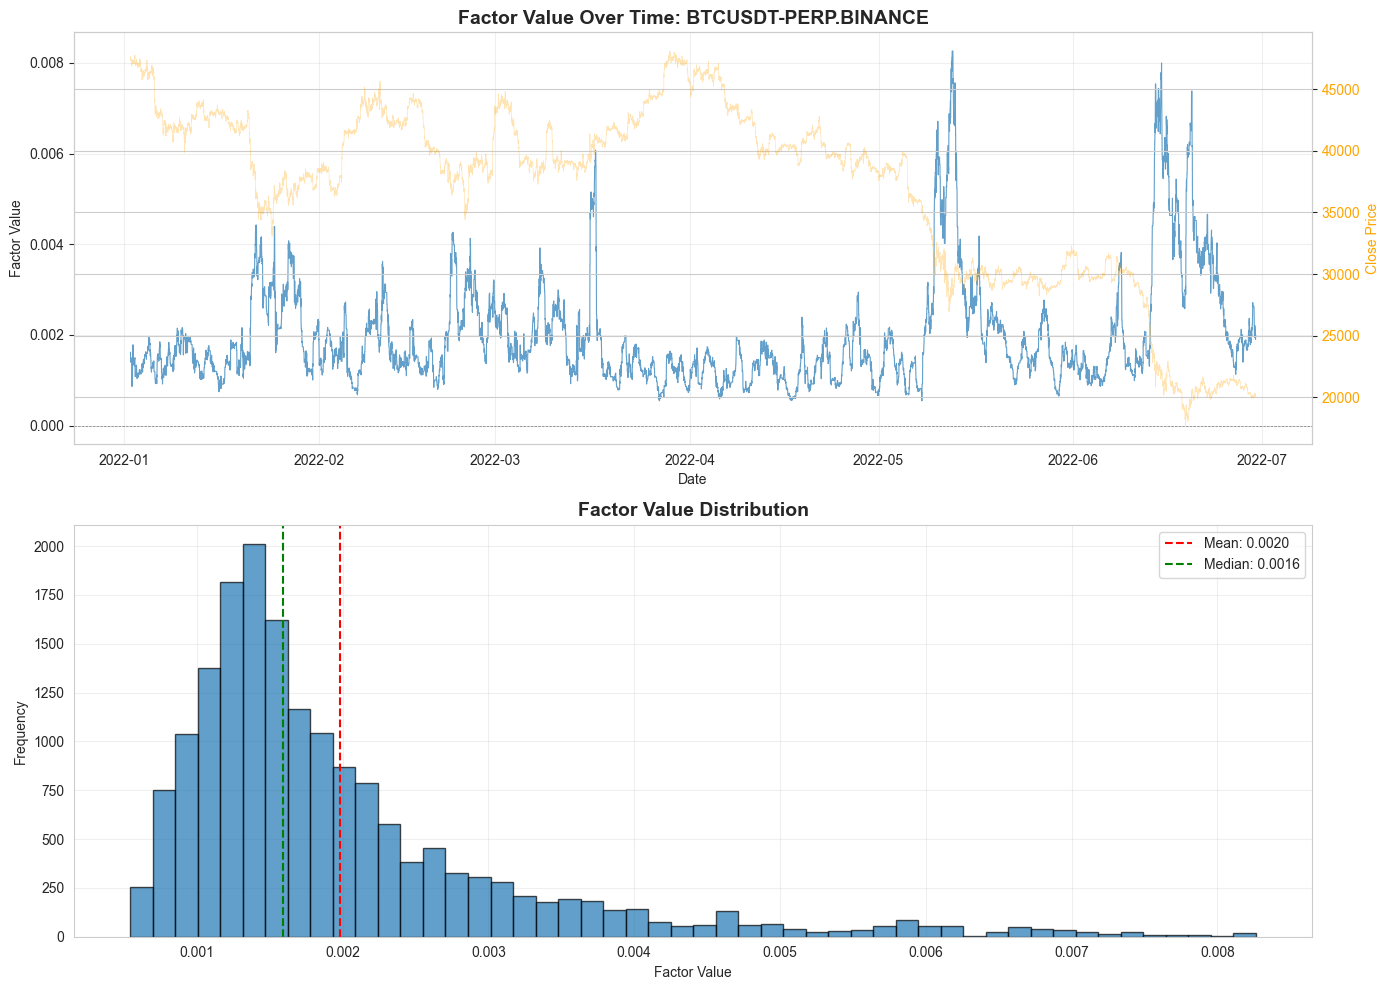

In [55]:
# ============================================================================
# 4. Visualization
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Factor value over time
axes[0].plot(result['ts_event'], result['factor_value'], linewidth=0.8, alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
axes[0].set_title(f'Factor Value Over Time: {INSTRUMENT_ID}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Factor Value')
axes[0].grid(True, alpha=0.3)

# Price reference (optional - shows close price on secondary axis)
ax2 = axes[0].twinx()
ax2.plot(result['ts_event'], result['bar_close'], color='orange', alpha=0.3, linewidth=0.5)
ax2.set_ylabel('Close Price', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Distribution histogram
axes[1].hist(result['factor_value'].dropna(), bins=50, alpha=0.7, edgecolor='black')
axes[1].axvline(x=result['factor_value'].mean(), color='red', linestyle='--', 
                label=f'Mean: {result["factor_value"].mean():.4f}')
axes[1].axvline(x=result['factor_value'].median(), color='green', linestyle='--',
                label=f'Median: {result["factor_value"].median():.4f}')
axes[1].set_title('Factor Value Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Factor Value')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
# ============================================================================
# 5. NaN Analysis
# ============================================================================

is_nan = result['factor_value'].isna()
nan_transitions = is_nan.astype(int).diff().fillna(0)

# Find consecutive NaN runs
nan_runs = []
run_start = None

for idx, (is_nan_val, transition) in enumerate(zip(is_nan, nan_transitions)):
    if transition == 1:  # Start of NaN run
        run_start = idx
    elif transition == -1 and run_start is not None:  # End of NaN run
        nan_runs.append((run_start, idx - 1))
        run_start = None

# Handle case where NaN run extends to end
if run_start is not None:
    nan_runs.append((run_start, len(is_nan) - 1))

print("NaN Analysis:")
print("=" * 70)
print(f"Total NaN values: {is_nan.sum()}")
print(f"Number of NaN runs: {len(nan_runs)}")

if nan_runs:
    run_lengths = [end - start + 1 for start, end in nan_runs]
    print(f"\nLongest NaN run: {max(run_lengths)} bars")
    print(f"Average NaN run length: {np.mean(run_lengths):.2f} bars")
    print(f"\nFirst 5 NaN runs (start_idx, end_idx, length):")
    for i, (start, end) in enumerate(nan_runs[:5]):
        print(f"  Run {i+1}: ({start}, {end}, {end-start+1} bars)")
else:
    print("\n✅ No NaN values found in factor output")

NaN Analysis:
Total NaN values: 0
Number of NaN runs: 0

✅ No NaN values found in factor output


In [ ]:
# ============================================================================
# 6. Export Results (Optional)
# ============================================================================

output_dir = research_dir / "results"
output_dir.mkdir(exist_ok=True)

# Generate filename with timestamp
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
instrument_clean = INSTRUMENT_ID.replace(".", "_").replace("-", "_")
output_file = output_dir / f"factor_{instrument_clean}_{timestamp}.feather"

# Save to feather format (fast, compressed)
result.reset_index(drop=True).to_feather(output_file)

print(f"✅ Results saved to: {output_file}")
print(f"File size: {output_file.stat().st_size / 1024:.2f} KB")

In [9]:
# ============================================================================、
# 7. Compare with Baseline Data
# ============================================================================
# 创建一个函数，这个函数接受一个含有baseline数据的csv文件路径和一个result数据框，然后计算因子值的相对误差，并输出相关的统计信息
def compare_with_baseline(baseline_csv_path, result_df):
    baseline_df = pd.read_csv(baseline_csv_path)
    # 用iloc[:, 14:15]选择BTC永续合约的因子值列 
    baseline_df = baseline_df.iloc[:, 14:15]
    # 重命名列1为'factor_value'
    baseline_df.columns = ['factor_value']
    # 将baseline数据的index转换成从2022-01-01开始的时间戳，以15分钟为间隔
    baseline_df['ts_event'] = pd.date_range(start='2022-01-01', periods=len(baseline_df), freq='15T')

    # 假设baseline_df有两列：'ts_event'和'factor_value'，但是需要注意，baseline_df的'ts_event'列会更全，result_df可能缺少一些时间点，所以我们需要全部对齐之后去掉包含NaN的行
    merged_df = pd.merge(baseline_df, result_df[['ts_event', 'factor_value']], on='ts_event', how='inner', suffixes=('_baseline', '_computed'))
    # 去掉包含NaN的行
    merged_df = merged_df.dropna(subset=['factor_value_baseline', 'factor_value_computed'])
    
    # 计算相对误差
    merged_df['relative_error'] = np.abs(merged_df['factor_value_computed'] - merged_df['factor_value_baseline']) / np.abs(merged_df['factor_value_baseline'])
    
    # 输出统计信息
    print("Comparison with Baseline:")
    print("=" * 70)
    print(f"Total compared points: {len(merged_df)}")
    print(f"Mean Relative Error: {merged_df['relative_error'].mean():.6f}")
    print(f"Max Relative Error: {merged_df['relative_error'].max():.6f}")
    print(f"Min Relative Error: {merged_df['relative_error'].min():.6f}")
    print(f"Standard Deviation of Relative Error: {merged_df['relative_error'].std():.6f}")
    
    return merged_df

In [40]:
# read /Users/arandott/Desktop/documents_for_work/Chaochien/nautilus_trader/factorexp_backtest/data/smtmny1_abs_ret_to_volume_vwap_ret_abs_mean_shigh_96.csv
df = pd.read_csv("/Users/arandott/Desktop/documents_for_work/Chaochien/nautilus_trader/factorexp_backtest/data/mean_selq.csv")
df.iloc[288:, 14:15]

,13
288,0.001278
289,0.001278
290,0.001313
291,0.001305
292,0.001305
...,...
112795,0.001221
112796,0.001228
112797,0.001228
112798,0.001230


In [58]:
# read /Users/arandott/Desktop/documents_for_work/Chaochien/nautilus_trader/factorexp_backtest/data/smtmny1_abs_ret_to_volume_vwap_ret_abs_mean_shigh_96.csv
baseline_file = "/Users/arandott/Desktop/documents_for_work/Chaochien/nautilus_trader/factorexp_backtest/data/mean_selq.csv"
comparison_df = compare_with_baseline(baseline_file, result)
comparison_df.head()

Comparison with Baseline:
Total compared points: 16983
Mean Relative Error: 0.000749
Max Relative Error: 0.394758
Min Relative Error: 0.000000
Standard Deviation of Relative Error: 0.012599


/var/folders/n7/13t3mbqj2llb9l684581_7700000gn/T/ipykernel_61782/3713392696.py:12: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  baseline_df['ts_event'] = pd.date_range(start='2022-01-01', periods=len(baseline_df), freq='15T')


,factor_value_baseline,ts_event,factor_value_computed,relative_error
192,0.001278,2022-01-04 00:00:00,0.001278,0.000003
193,0.001278,2022-01-04 00:15:00,0.001278,0.000003
194,0.001313,2022-01-04 00:30:00,0.001313,0.000005
195,0.001305,2022-01-04 00:45:00,0.001305,0.000004
196,0.001305,2022-01-04 01:00:00,0.001305,0.000004


# ============================================================================
# Usage Guide
# ============================================================================

## Evaluating Different Expressions

Simply change the expression in Cell 5:

```python
# Try these examples:
result = evaluate_factor(VOLATILITY, INSTRUMENT_ID, START_DATE, END_DATE, verbose=True)
result = evaluate_factor(VWAP_RETURN, INSTRUMENT_ID, START_DATE, END_DATE, verbose=True)
```

## Comparing Multiple Instruments

Change `INSTRUMENT_ID` in Cell 1 and re-run all cells

## Next Steps

1. **Validate Expression**: Ensure factor values match expectations
2. **Analyze NaN Patterns**: Understand when and why NaN values occur
3. **Check Distribution**: Verify factor values are properly normalized
4. **Use in Backtest**: Copy validated expression to `factorexp_backtest/configs/factors.yaml`